# <font color='red'> Data Preprocessing methods </font>

## <font color='blue'> Import Libraries </font>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# import dataset

In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.shape)

(768, 9)


#Inspect data structure and check missing values

In [4]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0


# Statistical summary and visualizing outliers
###df.describe()- displays statistical value

###boxplots - visualize spread and detect outliers

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


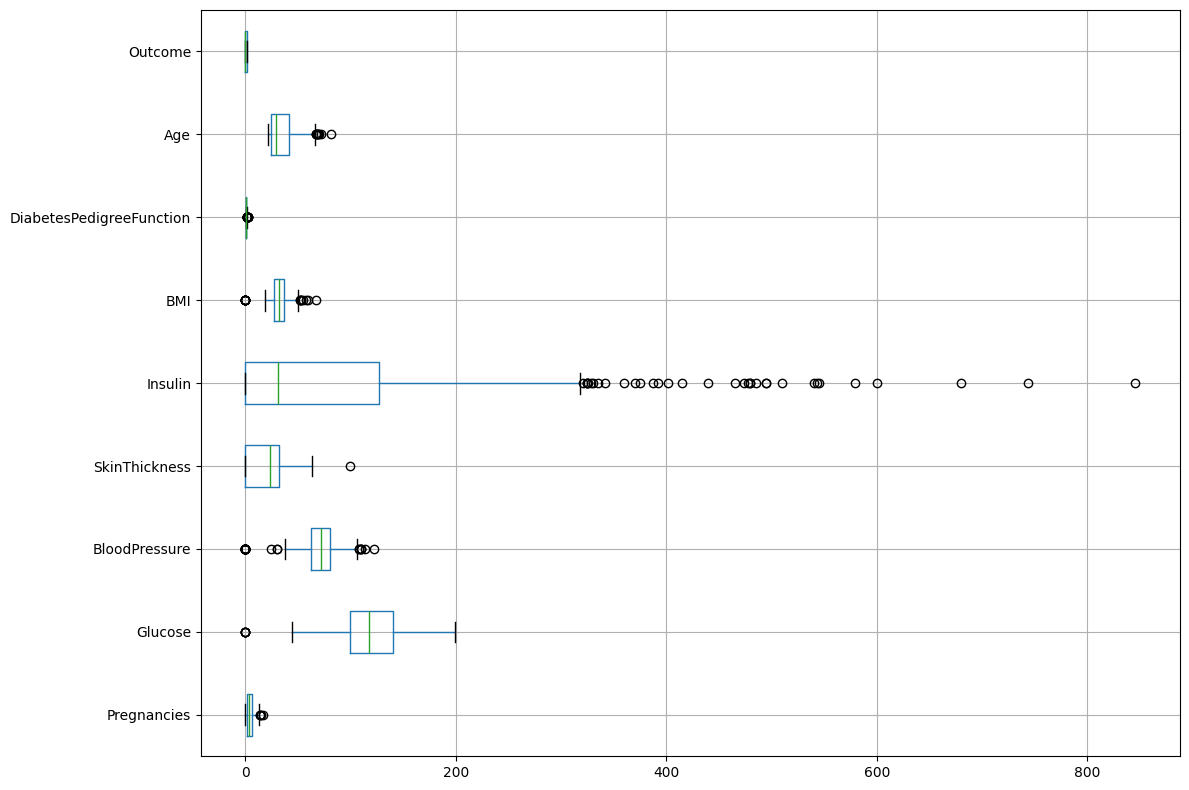

In [6]:
df.boxplot(figsize=(12,8),vert=False)
plt.tight_layout()
plt.show()

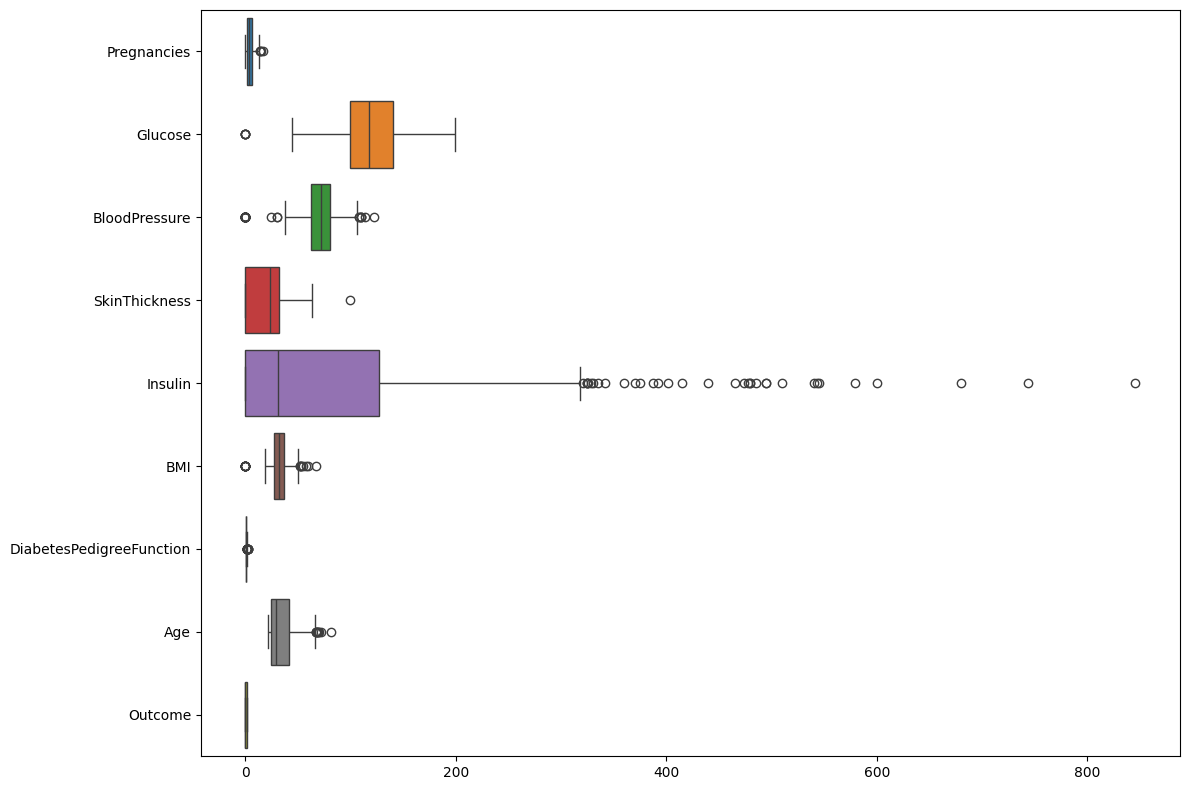

In [7]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,orient="h")
plt.tight_layout()
plt.show()

#<font color='red'> Remove outliers using the Interquartile Range (IQR) Method</font>
IQR=Q3 (75th percentile)  Q1- (25th percentile)
## Values below Q!-1.51QR or above Q3+1.5IQR are outliers
## Calculate lower and upper bounds for each column separately
## filter data points to keep only those within bounds

In [8]:
q1,q3=np.percentile(df['Insulin'],[25,75])
iqr=q3-q1
lower=q1 - 1.5 * iqr
upper=q3 - 1.5 * iqr
clean_df=df[(df['Insulin']>=lower) & (df['Insulin']<=upper)]
print(lower)
print(upper)

-190.875
-63.625


# correlation analysis

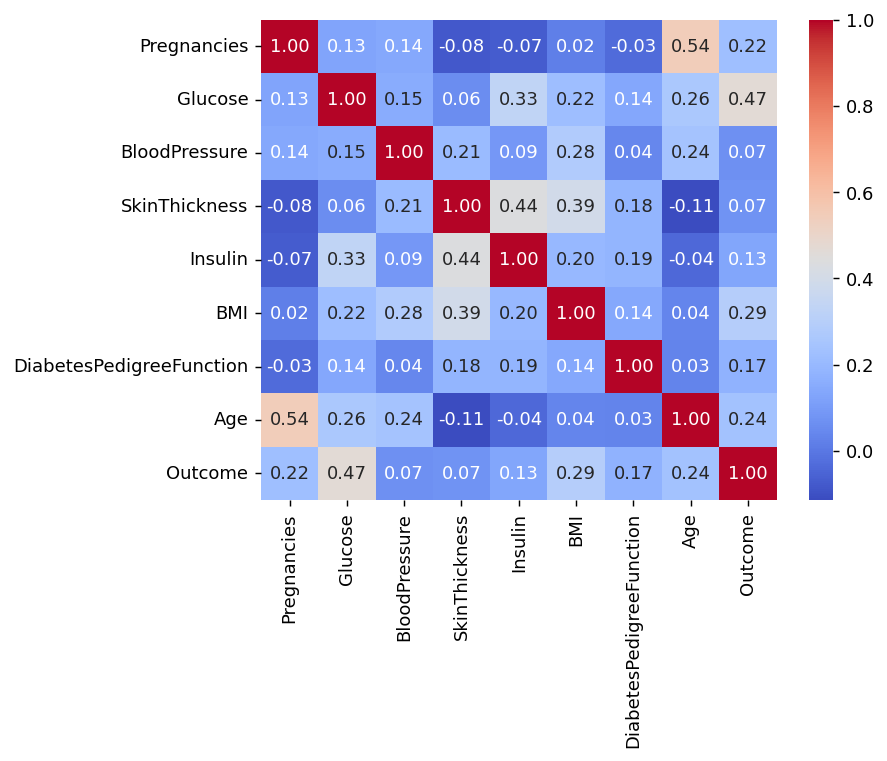

In [20]:
corr=df.corr()
plt.figure(dpi=130)
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()


# Visualize target variable distribution

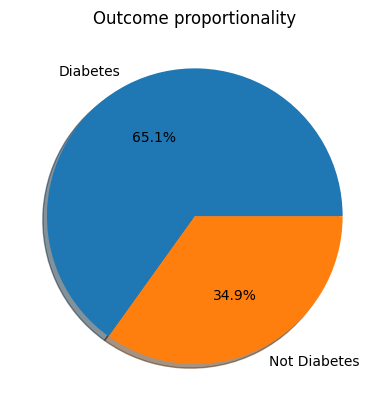

In [22]:
plt.pie(df['Outcome'].value_counts(),labels=['Diabetes','Not Diabetes'],autopct='%1.1f%%',shadow=True)
plt.title('Outcome proportionality')
plt.show()

# Separate Features and Target Variable

In [24]:
X=df.drop(columns=['Outcome'])
y=df['Outcome']

#Feature scaling : Normalization and Standardization

In [25]:
scaler=MinMaxScaler()
X_normalized=scaler.fit_transform(X)
print(X_normalized[:5])

[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


# Standardization

In [26]:
scaler=StandardScaler()
X_standardized=scaler.fit_transform(X)
print(X_standardized[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
